# Imports

In [1]:
from pathlib import Path
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import arff
import numpy as np

from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.cluster import KMeans
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)

# Data loading

In [27]:
ROOT = Path.cwd()

if ROOT.name == 'notebooks':
    DATA_PATH = ROOT.parent / 'credit'
else:
    DATA_PATH = 'credit'
    
with open(DATA_PATH, 'r') as f:
    arff_data = arff.load(f)
    
data = arff_data['data']
column_names = [attr[0] for attr in arff_data['attributes']]
    
df = pd.DataFrame(data, columns=column_names)

df["Loan_Amount_Requested"] = (
    df["Loan_Amount_Requested"]
      .str.replace(",", "")
      .astype(float)
)

df.head()

,Loan_ID,Loan_Amount_Requested,Length_Employed,Home_Owner,Annual_Income,Income_Verified,Purpose_Of_Loan,Debt_To_Income,Inquiries_Last_6Mo,Months_Since_Deliquency,Number_Open_Accounts,Total_Accounts,Gender,Interest_Rate
0,10139122,35000.0,3 years,NaN,160000.0,VERIFIED - income,credit_card,14.86,1,NaN,6,26,Male,None
1,10025461,15000.0,10+ years,Rent,41000.0,not verified,debt_consolidation,16.51,0,21.0,13,36,Female,None
2,10154747,11000.0,5 years,Mortgage,59000.0,not verified,debt_consolidation,21.75,0,NaN,11,20,Male,None
3,10032437,12000.0,NaN,Mortgage,72000.0,VERIFIED - income,debt_consolidation,15.73,1,NaN,7,20,Female,None
4,10060564,20000.0,< 1 year,Other,79404.0,VERIFIED - income,debt_consolidation,15.32,3,58.0,18,33,Female,None


# Target setup

In [28]:
# Usuwamy rekordy bez dochodu

df_model = df.dropna(subset=["Annual_Income"]).copy()

median_income = df_model["Annual_Income"].median()

df_model["High_Income"] = (
    df_model["Annual_Income"] >= median_income
).astype(int)

df_model["High_Income"].value_counts(normalize=True)

High_Income
1    0.506883
0    0.493117
Name: proportion, dtype: float64

# X and y prep

In [29]:
X = df_model.drop(
    columns=[
        "Loan_ID",
        "Annual_Income",
        "High_Income",
        "Interest_Rate",
    ],
    errors="ignore"
)

y = df_model["High_Income"]

X.head()

,Loan_Amount_Requested,Length_Employed,Home_Owner,Income_Verified,Purpose_Of_Loan,Debt_To_Income,Inquiries_Last_6Mo,Months_Since_Deliquency,Number_Open_Accounts,Total_Accounts,Gender
0,35000.0,3 years,NaN,VERIFIED - income,credit_card,14.86,1,NaN,6,26,Male
1,15000.0,10+ years,Rent,not verified,debt_consolidation,16.51,0,21.0,13,36,Female
2,11000.0,5 years,Mortgage,not verified,debt_consolidation,21.75,0,NaN,11,20,Male
3,12000.0,NaN,Mortgage,VERIFIED - income,debt_consolidation,15.73,1,NaN,7,20,Female
4,20000.0,< 1 year,Other,VERIFIED - income,debt_consolidation,15.32,3,58.0,18,33,Female


# train/test split

In [30]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(20920, 11)
(6974, 11)


# Base model (without preprocessing)

In [31]:
X_train_base = X_train.copy()
X_test_base = X_test.copy()

numeric_cols = X_train_base.select_dtypes(
    include=["int64", "float64"]
).columns

X_train_base = X_train_base[numeric_cols]
X_test_base = X_test_base[numeric_cols]

X_train_base = X_train_base.fillna(
    X_train_base.median()
)

X_test_base = X_test_base.fillna(
    X_train_base.median()
)

In [32]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

baseline = RandomForestClassifier(
    random_state=42
)

baseline.fit(X_train_base, y_train)

pred_base = baseline.predict(X_test_base)

print(
    "Baseline accuracy:",
    accuracy_score(y_test, pred_base)
)

Baseline accuracy: 0.7145110410094637


# Pipeline with ColumnTransformer

In [35]:
numeric_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object", "string"]
).columns.tolist()

print(numeric_features)
print(categorical_features)

['Loan_Amount_Requested', 'Debt_To_Income', 'Inquiries_Last_6Mo', 'Months_Since_Deliquency', 'Number_Open_Accounts', 'Total_Accounts']
['Length_Employed', 'Home_Owner', 'Income_Verified', 'Purpose_Of_Loan', 'Gender']


In [36]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

In [37]:
preprocess = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler())
            ]),
            numeric_features
        ),
        (
            "cat",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore"))
            ]),
            categorical_features
        )
    ]
)

In [38]:
from sklearn.linear_model import LogisticRegression

model = Pipeline([
    ("preprocess", preprocess),
    ("clf", LogisticRegression(max_iter=2000))
])

model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contai

# Quality check

In [39]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
)

pred = model.predict(X_test)
proba = model.predict_proba(X_test)[:,1]

print(
    "Accuracy:",
    accuracy_score(y_test, pred)
)

print(
    classification_report(y_test, pred)
)

Accuracy: 0.7304273014052194
              precision    recall  f1-score   support

           0       0.72      0.74      0.73      3439
           1       0.74      0.72      0.73      3535

    accuracy                           0.73      6974
   macro avg       0.73      0.73      0.73      6974
weighted avg       0.73      0.73      0.73      6974



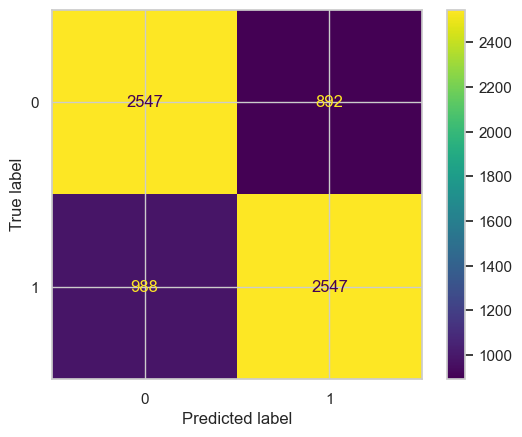

In [40]:
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay
)

cm = confusion_matrix(y_test, pred)

ConfusionMatrixDisplay(cm).plot()
plt.show()

# Model comparison

In [41]:
comparison = pd.DataFrame({
    "model": [
        "Baseline RF",
        "Logistic + Preprocessing"
    ],
    "accuracy": [
        accuracy_score(y_test, pred_base),
        accuracy_score(y_test, pred)
    ]
})

comparison

,model,accuracy
0,Baseline RF,0.714511
1,Logistic + Preprocessing,0.730427


# Feature interpretation

In [42]:
feature_names = model.named_steps[
    "preprocess"
].get_feature_names_out()

coefs = pd.Series(
    model.named_steps["clf"].coef_[0],
    index=feature_names
).sort_values(
    key=np.abs,
    ascending=False
)

coefs.head(15)

num__Loan_Amount_Requested                 1.108901
num__Debt_To_Income                       -0.678061
num__Total_Accounts                        0.514051
cat__Purpose_Of_Loan_vacation              0.490005
cat__Purpose_Of_Loan_debt_consolidation   -0.405882
cat__Purpose_Of_Loan_credit_card          -0.335902
cat__Home_Owner_Mortgage                   0.334264
cat__Home_Owner_Own                       -0.314608
cat__Purpose_Of_Loan_small_business       -0.238562
cat__Purpose_Of_Loan_medical               0.236179
cat__Home_Owner_Other                      0.196010
num__Number_Open_Accounts                  0.168141
cat__Length_Employed_10+ years             0.160457
cat__Length_Employed_9 years               0.159722
cat__Purpose_Of_Loan_educational          -0.147251
dtype: float64

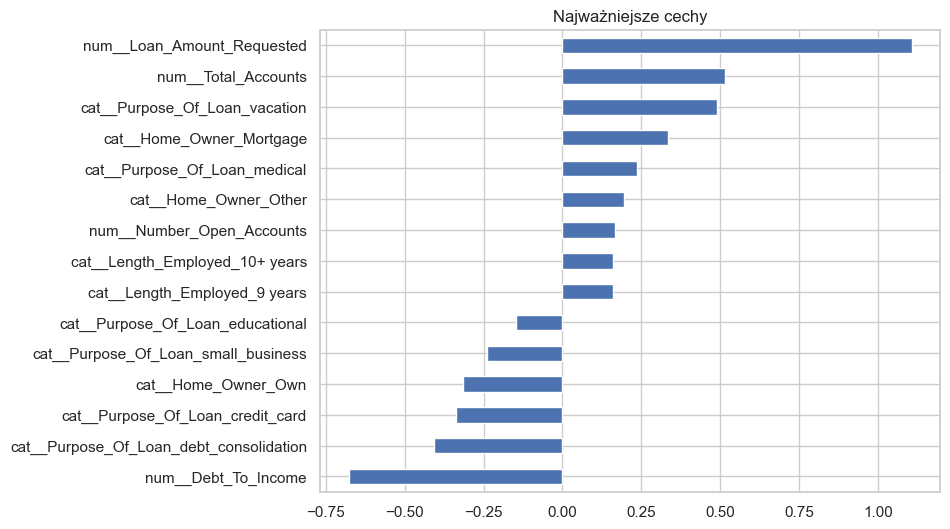

In [43]:
coefs.head(15).sort_values().plot(
    kind="barh",
    figsize=(8,6)
)

plt.title("Najważniejsze cechy")
plt.show()

In [44]:
report = pd.DataFrame({
    "metric": ["accuracy"],
    "value": [
        accuracy_score(y_test, pred)
    ]
})

report

,metric,value
0,accuracy,0.730427


# Drift

In [47]:
from scipy import stats

feature = "Debt_To_Income"

ks = stats.ks_2samp(
    X_train[feature].dropna(),
    X_test[feature].dropna()
)

print(ks)

KstestResult(statistic=np.float64(0.012603231012101146), pvalue=np.float64(0.3740316776397563), statistic_location=np.float64(20.51), statistic_sign=np.int8(-1))


In [46]:
shifts = pd.DataFrame({
    "dti_scale": [1.00, 1.05, 1.10, 1.15]
})

results = []

for _, row in shifts.iterrows():

    X_shift = X_test.copy()

    X_shift["Debt_To_Income"] *= row["dti_scale"]

    pred_shift = model.predict(X_shift)

    acc = accuracy_score(
        y_test,
        pred_shift
    )

    ks = stats.ks_2samp(
        X_train["Debt_To_Income"].dropna(),
        X_shift["Debt_To_Income"].dropna()
    )

    results.append({
        "scale": row["dti_scale"],
        "accuracy": acc,
        "ks_stat": ks.statistic,
        "ks_pvalue": ks.pvalue
    })

results_df = pd.DataFrame(results)

results_df

,scale,accuracy,ks_stat,ks_pvalue
0,1.00,0.730427,0.012603,3.740317e-01
1,1.05,0.732435,0.037438,8.345748e-07
2,1.10,0.734299,0.076635,3.682842e-27
3,1.15,0.733152,0.113967,1.245996e-59
